In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob, os

# ── Output directory containing parquet files ─────────────────────────────
# LOCAL (Mac):  /Users/sumanshrestha/Desktop/test_output
# iFarm:        /volatile/clas12/rg-d/<username>/parquet_output   # <-- CHANGE THIS on iFarm
PARQUET_DIR = '/Users/sumanshrestha/Desktop/test_output'  # <-- CHANGE THIS PATH

# ── Target and polarity ───────────────────────────────────────────────────
TARGET   = 'LD2'   # e.g. LD2, LH2                    # <-- CHANGE if different target
POLARITY = 'OB'    # OB (outbending) or IB (inbending) # <-- CHANGE if different polarity

# ── Experimental data file ────────────────────────────────────────────────
# LOCAL (Mac):  sidis_LD2_OB_testnewLD2.root.parquet
# iFarm:        update filename to match your experimental parquet  # <-- CHANGE THIS on iFarm
DATA_FILE = os.path.join(PARQUET_DIR, f'sidis_{TARGET}_{POLARITY}_testnewLD2.root.parquet')  # <-- CHANGE FILENAME

# ── Load simulation reco parquet files (all files) ───────────────────────
reco_files = sorted(glob.glob(os.path.join(PARQUET_DIR, f'reco_sidis_{TARGET}_{POLARITY}_*.parquet')))

if not reco_files:
    raise FileNotFoundError(f'No reco parquet files found in {PARQUET_DIR}')
if not os.path.exists(DATA_FILE):
    raise FileNotFoundError(f'Experimental data file not found: {DATA_FILE}')

reco = pd.concat([pd.read_parquet(f) for f in reco_files], ignore_index=True)
data = pd.read_parquet(DATA_FILE)

# Keep only rows with a matched pion
reco_pip = reco[reco['w_pip'] == 1].copy()
data_pip = data[data['w_pip'] == 1].copy()

print(f'Loaded {len(reco_files)} reco sim files')
print(f'Reco rows : {len(reco_pip)}  (e+pi pairs passing all cuts)')
print(f'Data rows : {len(data_pip)}  (e+pi pairs passing all cuts)')

# ── Scattered electron energy: E_e = E_beam - nu ────────────────────────
E_BEAM = 10.54  # GeV  # <-- CHANGE if beam energy differs
reco_pip["e_E"] = E_BEAM - reco_pip["nu"]
data_pip["e_E"] = E_BEAM - data_pip["nu"]


Loaded 21 reco sim files
Reco rows : 17256  (e+pi pairs passing all cuts)
Data rows : 38630  (e+pi pairs passing all cuts)


In [2]:
# ── Cut control ──────────────────────────────────────────────────────────
# Set APPLY_DIS_CUTS / APPLY_SIDIS_CUTS to True or False to toggle cuts.
# Cut thresholds live in scripts/physics_constants.py  — change values there.
# Cut functions  live in scripts/common_cuts.py        — logic lives there.
import sys
sys.path.insert(0, "/Users/sumanshrestha/Library/CloudStorage/OneDrive-TempleUniversity/Final_Code/scripts")  # <-- CHANGE to your scripts path on iFarm
from analysis_cuts import apply_dis_cuts, apply_sidis_cuts, get_active_cuts

APPLY_DIS_CUTS   = True   # <-- SET False to see full kinematics
APPLY_SIDIS_CUTS = True   # <-- SET False to skip zh, pT2 cuts

def prepare(df):
    """Apply cuts based on flags above. Returns a copy of df."""
    if APPLY_SIDIS_CUTS:
        return apply_sidis_cuts(df)  # DIS + SIDIS cuts
    elif APPLY_DIS_CUTS:
        return apply_dis_cuts(df)    # DIS cuts only
    return df.copy()                 # no cuts — full kinematics

reco_plot = prepare(reco_pip)
data_plot = prepare(data_pip)

print(f"Cut mode: DIS={APPLY_DIS_CUTS}, SIDIS={APPLY_SIDIS_CUTS}")
print(get_active_cuts())
print(f"Reco rows : {len(reco_plot)}")
print(f"Data rows : {len(data_plot)}")


Cut mode: DIS=True, SIDIS=True
Active cut set: 'standard'
  Q2  > 1.0 GeV^2
  W   > 2.0 GeV
  0.25 < y < 0.85
  0.3 < zh < 0.7
  pT2 < 1.2 GeV^2
Reco rows : 6070
Data rows : 5638


In [3]:
# ── Plot helper ────────────────────────────────────────────────────────────
def compare(var, bins, xlabel, title=None, log=False, xticks=None):
    """Overlay normalised reco (sim) vs data histogram + ratio panel."""
    r = reco_plot[var].dropna()
    d = data_plot[var].dropna()

    fig, axes = plt.subplots(1, 2, figsize=(12, 4),
                             gridspec_kw={'width_ratios': [3, 1]})

    # Left: overlay reco sim vs data
    ax = axes[0]
    kw = dict(bins=bins, histtype='step', density=True, linewidth=1.5)
    ax.hist(r, label='Reco (Sim)', color='tomato', **kw)
    ax.hist(d, label='Data',       color='black',  **kw)
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel('Normalised counts', fontsize=12)
    ax.set_title(title or var)
    ax.legend()
    if log: ax.set_yscale('log')

    # Right: ratio data / reco(sim) per bin
    ax2 = axes[1]
    r_h, edges = np.histogram(r, bins=bins, density=False)
    d_h, _     = np.histogram(d, bins=bins, density=False)
    centers = 0.5 * (edges[:-1] + edges[1:])
    with np.errstate(divide='ignore', invalid='ignore'):
        ratio = np.where(r_h > 0, d_h / r_h, np.nan)
    ax2.step(centers, ratio, where='mid', color='black')
    ax2.axhline(1, color='gray', linestyle='--', linewidth=0.8)
    ax2.set_xlabel(xlabel, fontsize=10)
    ax2.set_ylabel('Data / Reco', fontsize=10)
    ax2.set_title('Data / Sim ratio')
    ax2.set_ylim(0, None)

    if xticks is not None:
        ax.set_xticks(xticks)
        if len(axes) > 1: axes[1].set_xticks(xticks)
    plt.tight_layout()
    plt.show()

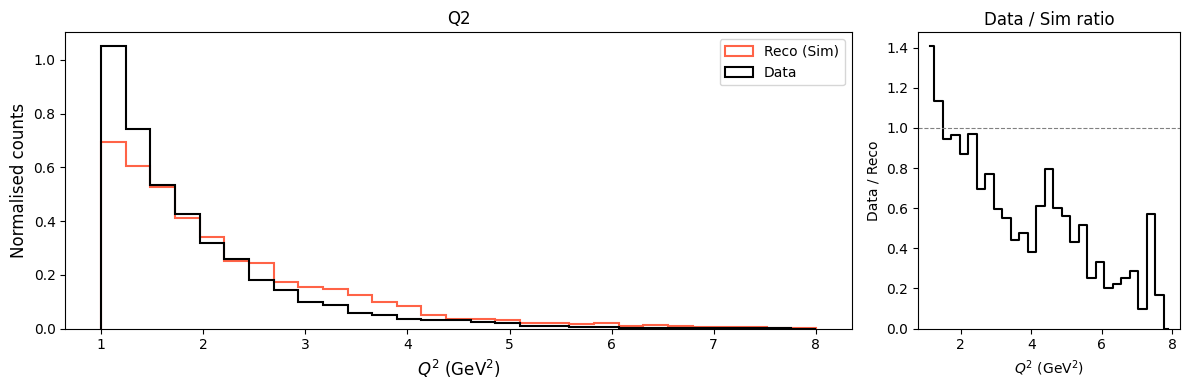

In [4]:
compare('Q2',    np.linspace(1,  8,  30), r'$Q^2$ (GeV$^2$)')

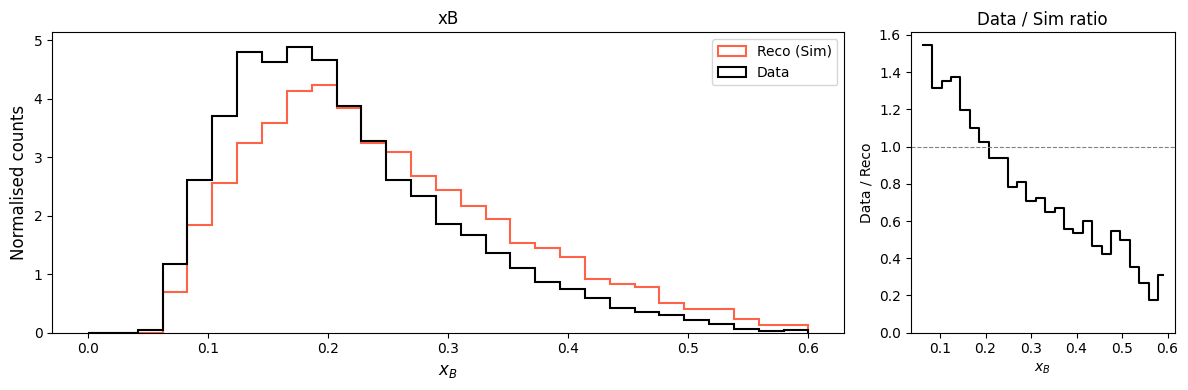

In [5]:
compare('xB',    np.linspace(0,  0.6, 30), r'$x_B$')

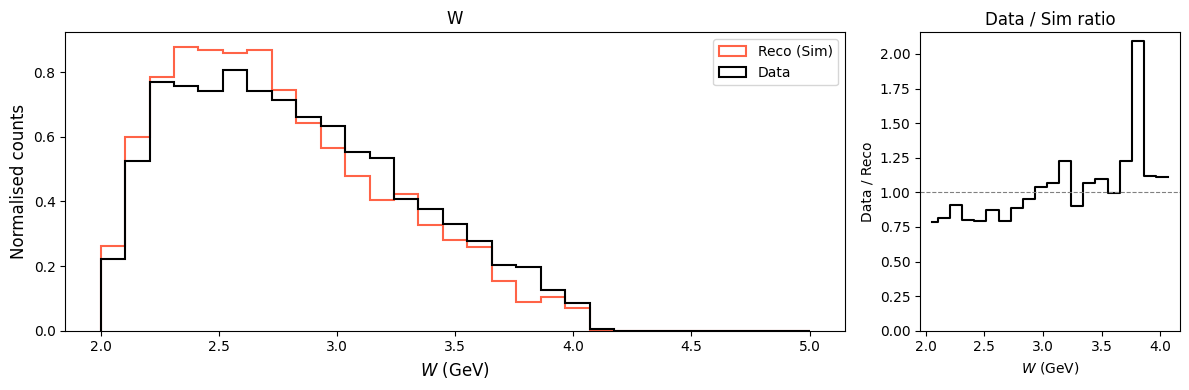

In [6]:
compare('W',     np.linspace(2,  5,  30), r'$W$ (GeV)')

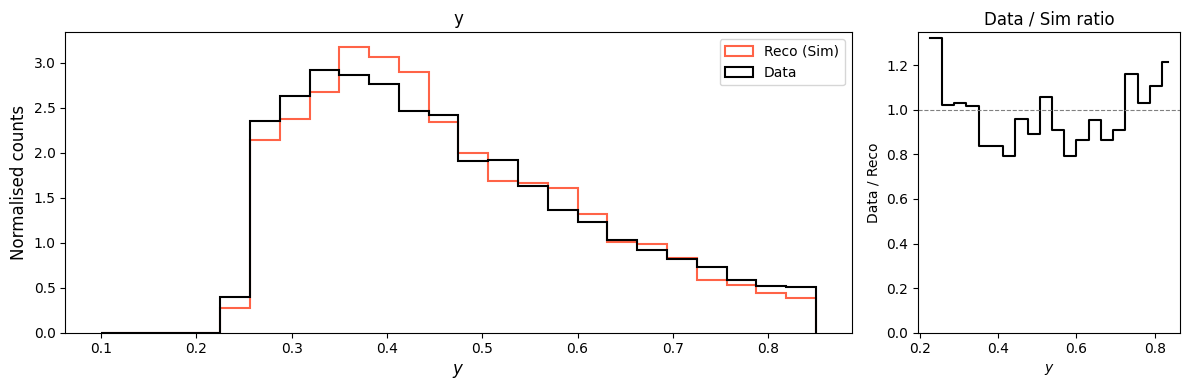

In [7]:
compare('y',     np.linspace(0.1, 0.85, 25), r'$y$')

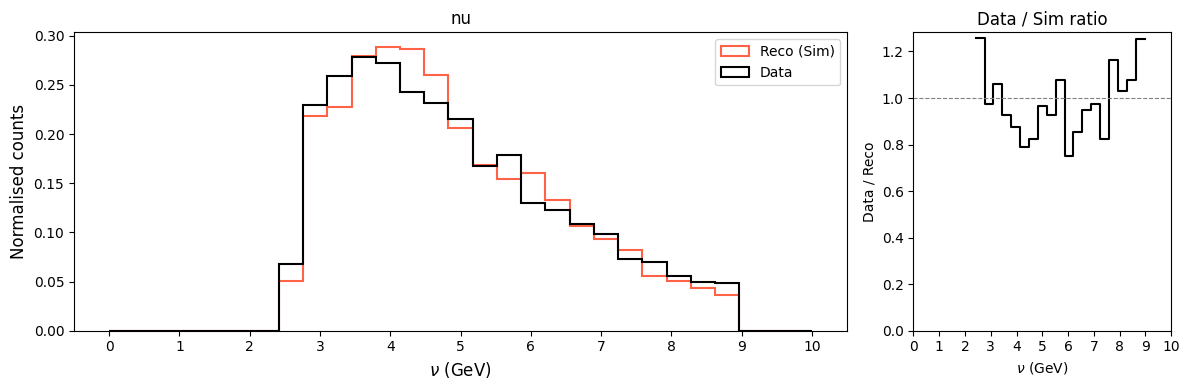

In [8]:
compare('nu', np.linspace(0, 10, 30), r'$\nu$ (GeV)', xticks=list(range(0, 11, 1)))


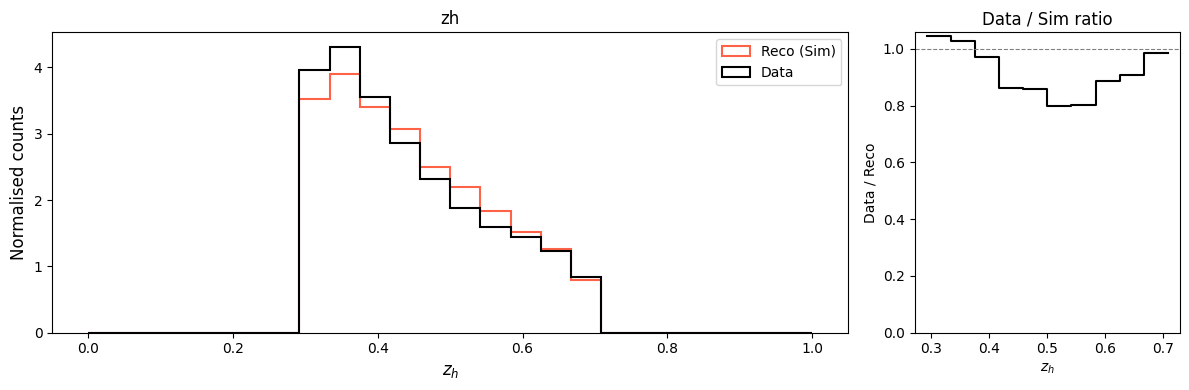

In [9]:
compare('zh',    np.linspace(0,  1,  25), r'$z_h$')

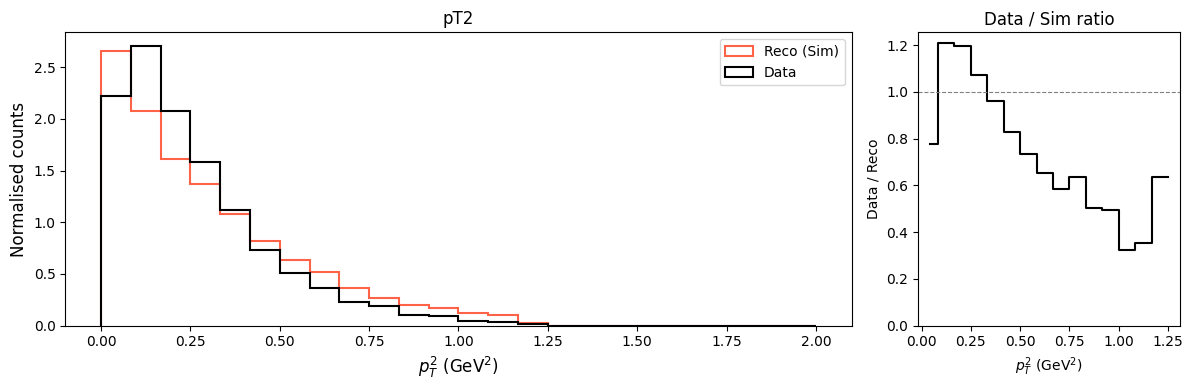

In [10]:
compare('pT2',   np.linspace(0,  2,  25), r'$p_T^2$ (GeV$^2$)')

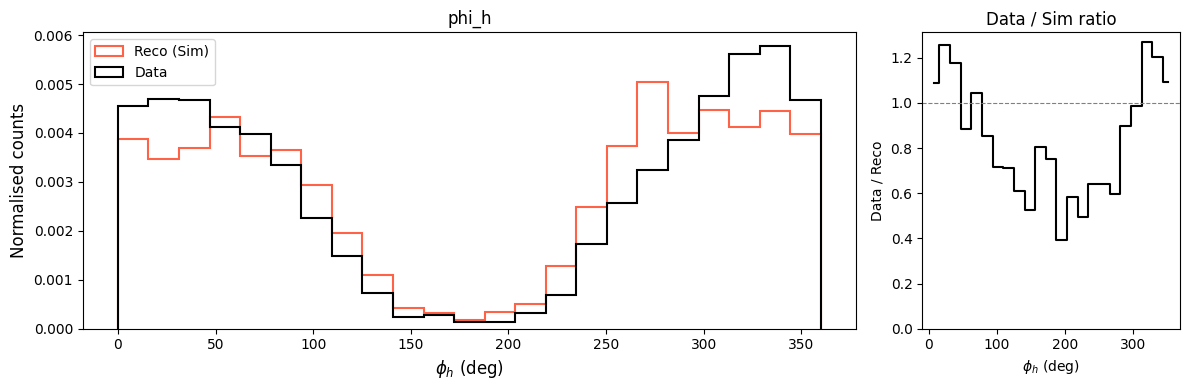

In [11]:
compare('phi_h', np.linspace(0, 360, 24), r'$\phi_h$ (deg)')

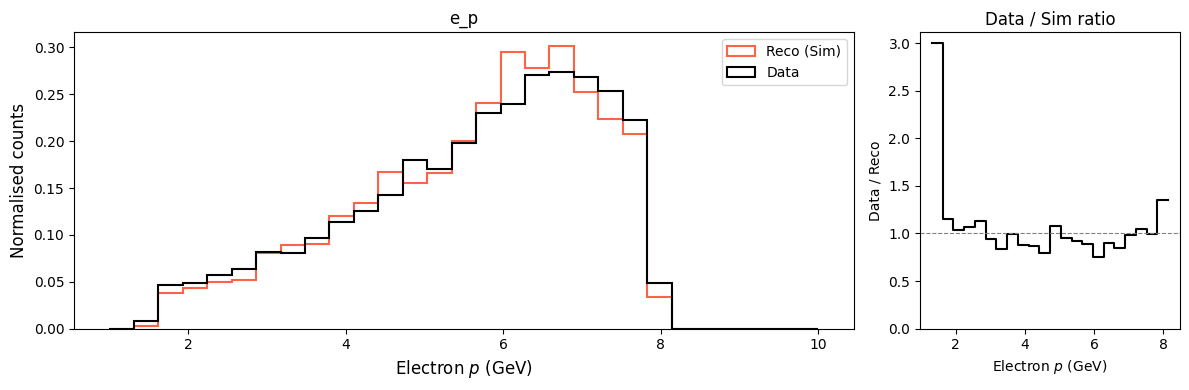

In [12]:
compare('e_p',   np.linspace(1, 10, 30), r'Electron $p$ (GeV)')

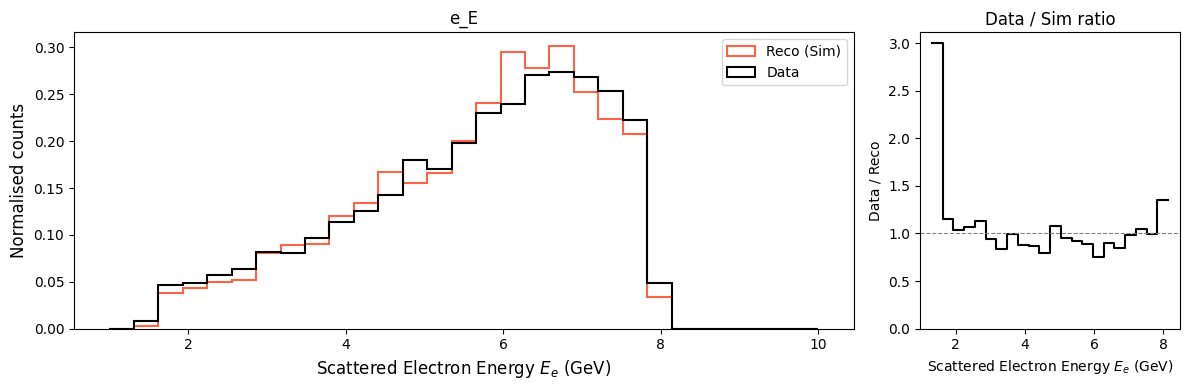

In [13]:
compare('e_E', np.linspace(1, 10, 30), r'Scattered Electron Energy $E_e$ (GeV)')


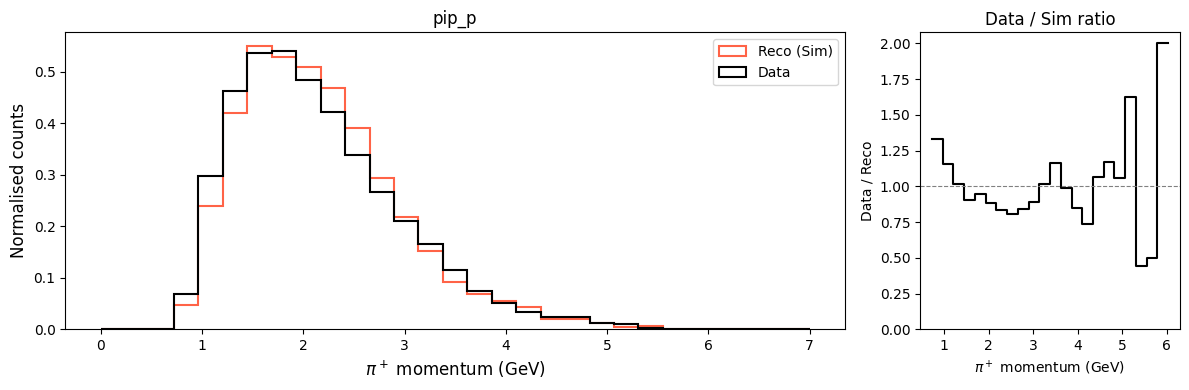

In [14]:
compare('pip_p', np.linspace(0, 7,  30), r'$\pi^+$ momentum (GeV)')

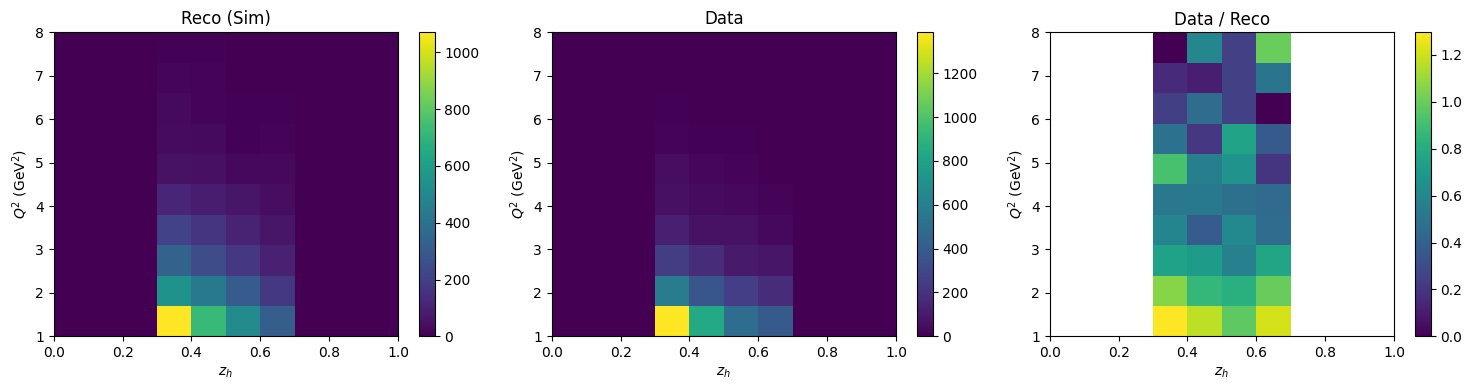

In [15]:
# ── 2D map: zh vs Q2  (Data / Reco ratio) ─────────────────────────────────
zh_bins = np.linspace(0, 1,  11)
q2_bins = np.linspace(1, 8,  11)

reco_h, _, _ = np.histogram2d(reco_plot['zh'], reco_plot['Q2'], bins=[zh_bins, q2_bins])
data_h, _, _ = np.histogram2d(data_plot['zh'], data_plot['Q2'], bins=[zh_bins, q2_bins])

with np.errstate(divide='ignore', invalid='ignore'):
    ratio2d = np.where(reco_h > 0, data_h / reco_h, np.nan)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, h, title in zip(axes,
                                [reco_h.T, data_h.T, ratio2d.T],
                                ['Reco (Sim)', 'Data', 'Data / Reco']):
    im = ax.pcolormesh(zh_bins, q2_bins, h, cmap='viridis')
    plt.colorbar(im, ax=ax)
    ax.set_xlabel(r'$z_h$')
    ax.set_ylabel(r'$Q^2$ (GeV$^2$)')
    ax.set_title(title)
plt.tight_layout()
plt.show()

In [16]:
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.pyplot as plt

# ── Save all plots to PDF ─────────────────────────────────────────────────
# Output saved to Final_Code folder. Change PDF_PATH on iFarm.
PDF_PATH = "/Users/sumanshrestha/Library/CloudStorage/OneDrive-TempleUniversity/Final_Code/03_data_vs_reco_cuts.pdf"  # <-- CHANGE on iFarm

def compare_to_pdf(var, bins, xlabel, pdf, title=None):
    """Same as compare() but saves figure to PDF instead of showing."""
    r = reco_plot[var].dropna()
    d = data_plot[var].dropna()
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), gridspec_kw={"width_ratios": [3, 1]})
    ax = axes[0]
    kw = dict(bins=bins, histtype="step", density=True, linewidth=1.5)
    ax.hist(r, label="Reco (Sim)", color="tomato", **kw)
    ax.hist(d, label="Data",       color="black",  **kw)
    ax.set_xlabel(xlabel, fontsize=12); ax.set_ylabel("Normalised counts", fontsize=12)
    ax.set_title(title or var); ax.legend()
    ax2 = axes[1]
    r_h, edges = np.histogram(r, bins=bins)
    d_h, _     = np.histogram(d, bins=bins)
    centers = 0.5 * (edges[:-1] + edges[1:])
    with np.errstate(divide="ignore", invalid="ignore"):
        ratio = np.where(r_h > 0, d_h / r_h, np.nan)
    ax2.step(centers, ratio, where="mid", color="black")
    ax2.axhline(1, color="gray", linestyle="--", linewidth=0.8)
    ax2.set_xlabel(xlabel, fontsize=10); ax2.set_ylabel("Data / Reco", fontsize=10)
    ax2.set_title("Data / Sim ratio"); ax2.set_ylim(0, None)
    plt.tight_layout()
    pdf.savefig(fig)
    plt.close(fig)

with PdfPages(PDF_PATH) as pdf:
    compare_to_pdf("Q2",    np.linspace(1,  8,  30), r"^2$ (GeV$)",         pdf)
    compare_to_pdf("xB",    np.linspace(0,  0.6, 30), r"$",                  pdf)
    compare_to_pdf("W",     np.linspace(2,  5,  30), r"$ (GeV)",               pdf)
    compare_to_pdf("y",     np.linspace(0.1, 0.85, 25), r"$",                  pdf)
    compare_to_pdf("nu",    np.linspace(0, 9, 30), r"$\nu$ (GeV)",             pdf)
    compare_to_pdf("zh",    np.linspace(0,  1,  25), r"$",                   pdf)
    compare_to_pdf("pT2",   np.linspace(0,  2,  25), r"^2$ (GeV$)",      pdf)
    compare_to_pdf("phi_h", np.linspace(0, 360, 24), r"$\phi_h$ (deg)",       pdf)
    compare_to_pdf("e_p",   np.linspace(1, 10, 30), r"Electron $ (GeV)",      pdf)
    compare_to_pdf("e_E",   np.linspace(1, 10, 30), r"Scattered Electron $ (GeV)", pdf)
    compare_to_pdf("pip_p", np.linspace(0, 7,  30), r"$\pi^+$ momentum (GeV)", pdf)
    # 2D Data/Reco map
    zh_bins = np.linspace(0, 1, 11)
    q2_bins = np.linspace(1, 8, 11)
    reco_h, _, _ = np.histogram2d(reco_plot["zh"], reco_plot["Q2"], bins=[zh_bins, q2_bins])
    data_h, _, _ = np.histogram2d(data_plot["zh"], data_plot["Q2"], bins=[zh_bins, q2_bins])
    with np.errstate(divide="ignore", invalid="ignore"):
        ratio2d = np.where(reco_h > 0, data_h / reco_h, np.nan)
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, d, title in zip(axes, [reco_h.T, data_h.T, ratio2d.T], ["Reco (Sim)", "Data", "Data / Reco"]):
        im = ax.pcolormesh(zh_bins, q2_bins, d, cmap="viridis")
        plt.colorbar(im, ax=ax)
        ax.set_xlabel(r"$"); ax.set_ylabel(r"^2$ (GeV$)")
        ax.set_title(title)
    plt.tight_layout()
    pdf.savefig(fig); plt.close(fig)

print(f"Saved PDF to {PDF_PATH}")


Saved PDF to /Users/sumanshrestha/Library/CloudStorage/OneDrive-TempleUniversity/Final_Code/03_data_vs_reco_cuts.pdf
